In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from claims_dashboard.simulate import MotorSimConfig, simulate_motor, write_processed
from claims_dashboard.data import load_processed
from claims_dashboard.metrics import add_derived_fields, kpis, monthly_trend

In [ ]:
# Configure and run simulation
cfg = MotorSimConfig(
    n_policies=60_000,
    start_date="2022-01-01",
    end_date="2025-12-31",
    seed=42,
)

policies, claims = simulate_motor(cfg)
write_processed(policies, claims, out_dir="../data/processed")

policies.head(), claims.head()

(   policy_id product state channel     cover_type driver_age_band  \
 0          0   Motor   QLD  Broker  Comprehensive           25-34   
 1          1   Motor   NSW  Broker           TPFT           50-64   
 2          2   Motor    WA  Broker            TPP           50-64   
 3          3   Motor   QLD  Agency  Comprehensive             65+   
 4          4   Motor   VIC  Broker  Comprehensive           50-64   
 
    vehicle_age  vehicle_value inception_date expiry_date  exposure_years  \
 0           19    6486.316905     2023-11-04  2024-10-26        0.977413   
 1           16    8673.293015     2025-12-28  2025-12-31        0.010000   
 2           12    9770.510401     2025-04-09  2025-12-31        0.728268   
 3           19    8263.670802     2024-05-18  2025-03-14        0.821355   
 4           19    9630.761426     2022-11-06  2023-06-29        0.643395   
 
    earned_premium  
 0      510.087304  
 1        5.115592  
 2      366.454555  
 3      443.799517  
 4      3

In [ ]:
# Load processed data and add derived fields
import matplotlib.pyplot as plt
import plotly.express as px

from claims_dashboard.data import load_processed
from claims_dashboard.metrics import add_derived_fields, kpis, monthly_trend

policies, claims = load_processed("../data/processed")
claims = add_derived_fields(claims)

policies.shape, claims.shape

((60000, 12), (4544, 13))

In [ ]:
# Calculate KPIs that will be used in dashboard
k = kpis(policies, claims)
k

{'exposure_years': 41746.12455852156,
 'earned_premium': 35351887.42895587,
 'n_claims': 4544,
 'incurred': 25034183.46164081,
 'paid': 14496750.072814856,
 'frequency_per_py': 0.1088484272026262,
 'avg_severity': 5509.283332227291,
 'loss_cost': 599.6768257265842,
 'loss_ratio': 0.708142769235453}

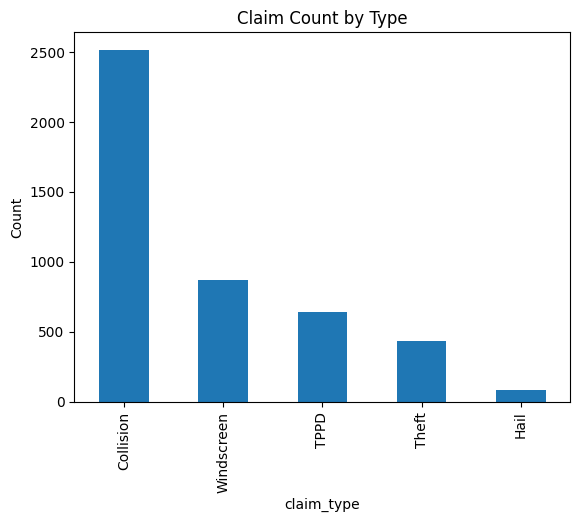

In [ ]:
# Plot claim count by type that will be used in dashboard
claims["claim_type"].value_counts().plot(kind="bar")
plt.title("Claim Count by Type")
plt.ylabel("Count")
plt.show()

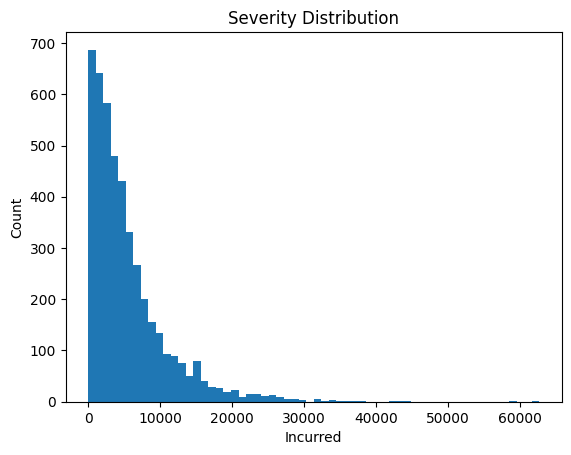

In [ ]:
# Plot severity distribution that will be used in dashboard
plt.hist(claims["incurred"], bins=60)
plt.title("Severity Distribution")
plt.xlabel("Incurred")
plt.ylabel("Count")
plt.show()

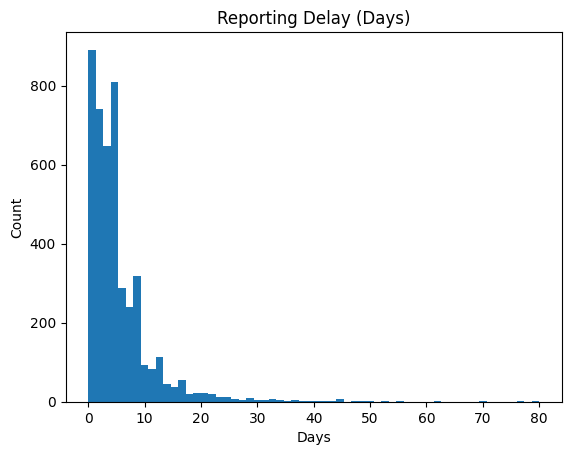

In [ ]:
# Plot reporting delay distribution that will be used in dashboard
plt.hist(claims["report_delay_days"].dropna(), bins=60)
plt.title("Reporting Delay (Days)")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

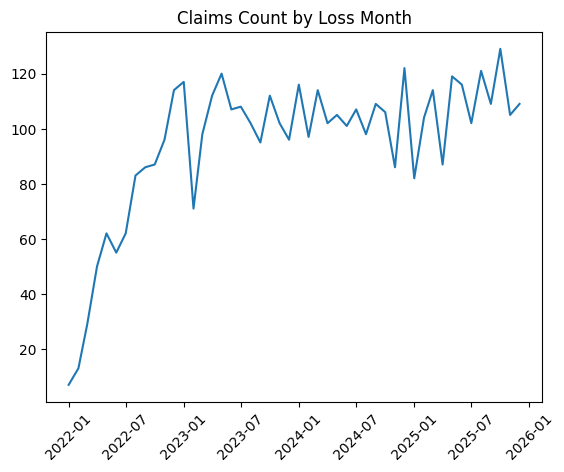

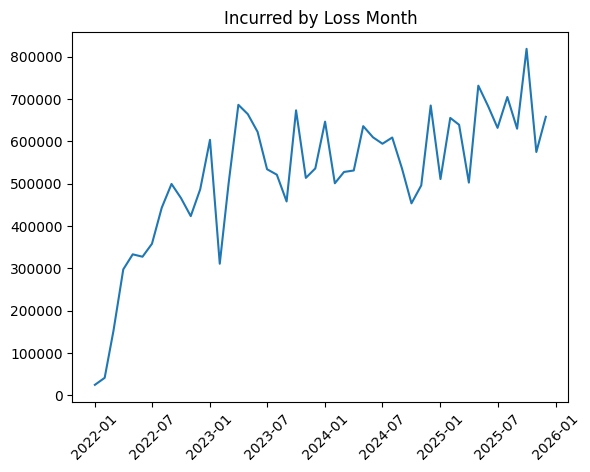

In [ ]:
# Plot monthly trends that will be used in dashboard
trend = monthly_trend(claims)

plt.plot(trend["loss_month"], trend["claims"])
plt.title("Claims Count by Loss Month")
plt.xticks(rotation=45)
plt.show()

plt.plot(trend["loss_month"], trend["incurred"])
plt.title("Incurred by Loss Month")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Example of filtering data for dashboard inputs
state_sel = ["VIC"]
cover_sel = ["Comprehensive"]

# merge dims onto claims
pol_dim = policies[[
    "policy_id", "state", "channel", "cover_type",
    "driver_age_band", "exposure_years", "earned_premium"
]]

df = claims.merge(pol_dim, on="policy_id", how="left")

df = df[df["state"].isin(state_sel)]
df = df[df["cover_type"].isin(cover_sel)]

pol_filt = policies[
    policies["state"].isin(state_sel)
    & policies["cover_type"].isin(cover_sel)
]

kpis(pol_filt, df)

{'exposure_years': 7651.266529774128,
 'earned_premium': 6708880.897910781,
 'n_claims': 897,
 'incurred': 4820052.996934947,
 'paid': 2786427.44073776,
 'frequency_per_py': 0.1172354925174042,
 'avg_severity': 5373.526195022237,
 'loss_cost': 629.967990028605,
 'loss_ratio': 0.7184585730886897}